# 01 — Ingestion & exploration Olist (Phase 2)

Ce notebook exécute le pipeline d'ingestion (`src/ingestion/ingest.py`) et de validation qualité (`src/ingestion/validate.py`), puis explore le dataset mergé.

**Aucun nettoyage de données n'est effectué ici** : c'est une phase d'ingestion, de merge et d'observation uniquement.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Le notebook est exécuté depuis notebooks/, donc la racine du projet est le
# dossier parent. On l'ajoute à sys.path pour pouvoir importer src.ingestion
# comme un package, exactement comme le font ingest.py et validate.py.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.ingestion import config, ingest, validate

pd.set_option("display.max_columns", None)

## 1. Ingestion : chargement des 8 CSV bruts + merge

In [2]:
merged_df = ingest.run_ingestion()
merged_df.shape

=== Ingestion Olist - 2026-07-21T13:24:02 ===

[idempotent] C:\Users\amenm\Desktop\Customer Intelligence Platform\Customer-Intelligence-Platform-End-to-End-Data-AI-Engineering-Project\data\processed\olist_merged.csv existe deja -> ingestion non relancee. Supprime ce fichier pour forcer une regeneration.


(119143, 37)

## 2. Validation qualité des données

Génère aussi le rapport `docs/data_quality_report.txt`.

In [3]:
validate.run_validation()

=== Validation qualite - olist_merged.csv - 2026-07-21T13:24:05 ===
Shape : (119143, 37)

--- Types de donnees ---
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
order_item_id                    float64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                         str
payment_installments             float64
payment_value           

## 3. Aperçu des tables brutes (`head(5)`)

In [4]:
raw_tables = ingest.load_all_tables()

for name, df in raw_tables.items():
    print(f"=== {name} — shape={df.shape} ===")
    display(df.head(5))

[customers] shape=(99441, 5) colonnes=['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


[orders] shape=(99441, 8) colonnes=['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
[order_items] shape=(112650, 7) colonnes=['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']


[order_payments] shape=(103886, 5) colonnes=['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value']


[order_reviews] shape=(99224, 7) colonnes=['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']
[products] shape=(32951, 9) colonnes=['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
[sellers] shape=(3095, 4) colonnes=['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']
[category_translation] shape=(71, 2) colonnes=['product_category_name', 'product_category_name_english']
=== customers — shape=(99441, 5) ===


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


=== sellers — shape=(3095, 4) ===


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


=== category_translation — shape=(71, 2) ===


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


## 4. Vue d'ensemble du dataset mergé

In [5]:
print("Shape :", merged_df.shape)
merged_df.dtypes

Shape : (119143, 37)


order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
order_item_id                    float64
product_id                           str
seller_id                            str
shipping_limit_date                  str
price                            float64
freight_value                    float64
payment_sequential               float64
payment_type                         str
payment_installments             float64
payment_value                    float64
review_id                            str
review_score                     float64
review_comment_t

In [6]:
merged_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
order_id,119143,99441,895ab968e7bb0d5659d16cd74cd1650c,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,119143,99441,270c23a11d024a44c896d1894b261a83,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_status,119143,8,delivered,115723,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_purchase_timestamp,119143,98875,2017-08-08 20:26:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_approved_at,118966,90733,2017-08-08 20:43:31,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_carrier_date,117057,81018,2017-08-10 11:58:14,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_delivered_customer_date,115722,95664,2017-08-14 12:46:18,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_estimated_delivery_date,119143,459,2017-12-20 00:00:00,663,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_unique_id,119143,96096,9a736b248f67d166d2fbb006bcb877c3,75,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_zip_code_prefix,119143.0,NaN,NaN,NaN,35033.451298,29823.198969,1003.0,11250.0,24240.0,58475.0,99990.0


## 5. Visualisations

`olist_merged.csv` a une ligne par (commande, article), donc plusieurs lignes peuvent partager le même `order_id` (multi-articles, multi-paiements, multi-avis). Pour les métriques qui portent sur la commande ou le client (statut, date de commande, état), on déduplique d'abord sur `order_id` / `customer_id` afin de ne pas surcompter.

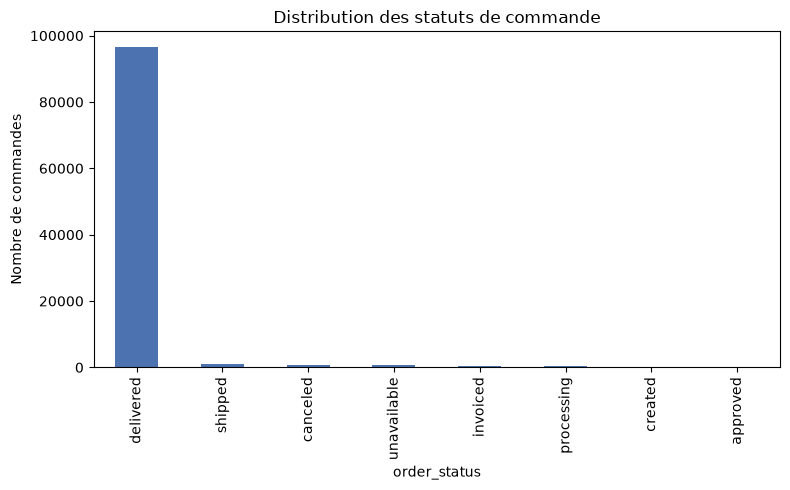

In [7]:
# --- Distribution des order_status (une ligne par commande) ---
orders_unique = merged_df.drop_duplicates("order_id")

fig, ax = plt.subplots(figsize=(8, 5))
orders_unique["order_status"].value_counts().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Distribution des statuts de commande")
ax.set_xlabel("order_status")
ax.set_ylabel("Nombre de commandes")
plt.tight_layout()
plt.show()

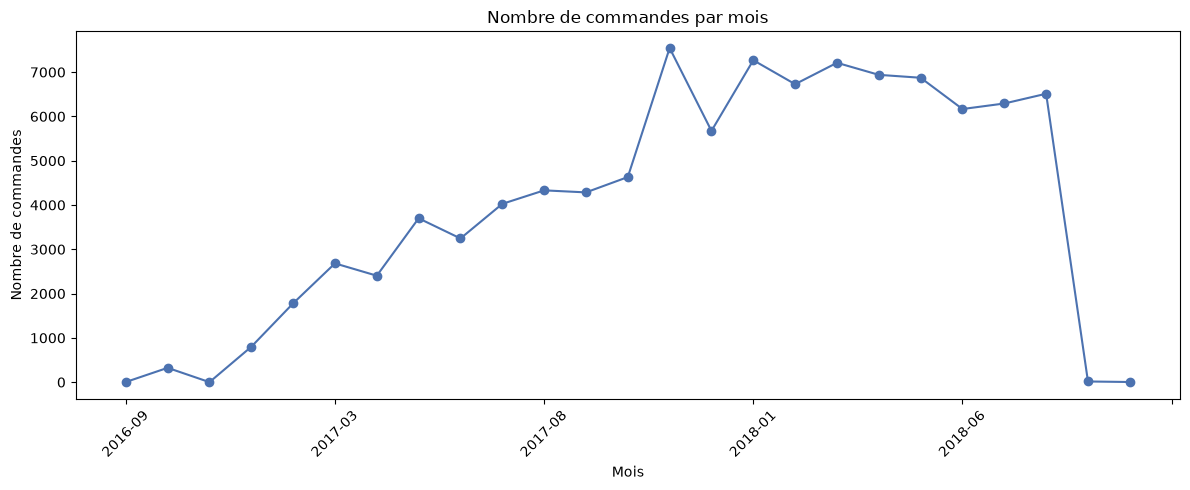

In [8]:
# --- Nombre de commandes par mois ---
orders_by_month = (
    orders_unique
    .assign(order_month=lambda d: pd.to_datetime(d["order_purchase_timestamp"]).dt.to_period("M").astype(str))
    .groupby("order_month")
    .size()
)

fig, ax = plt.subplots(figsize=(12, 5))
orders_by_month.plot(kind="line", marker="o", ax=ax, color="#4C72B0")
ax.set_title("Nombre de commandes par mois")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de commandes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

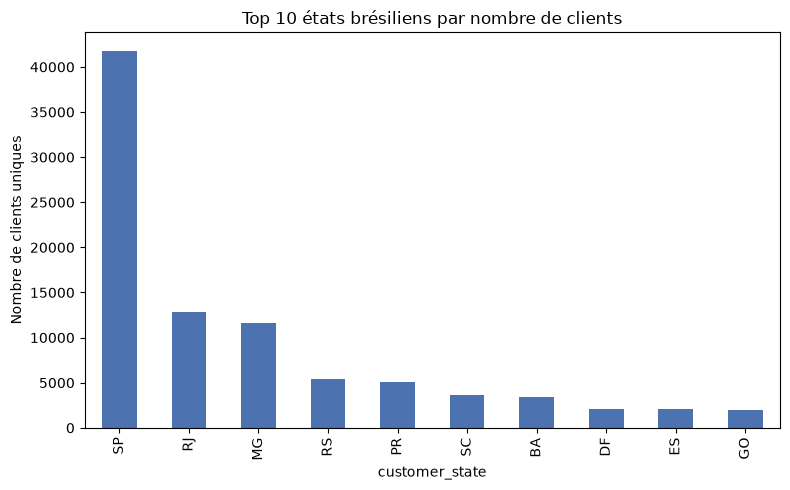

In [9]:
# --- Top 10 états brésiliens par nombre de clients ---
customers_unique = merged_df.drop_duplicates("customer_id")
top_states = customers_unique["customer_state"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(8, 5))
top_states.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Top 10 états brésiliens par nombre de clients")
ax.set_xlabel("customer_state")
ax.set_ylabel("Nombre de clients uniques")
plt.tight_layout()
plt.show()